<a href="https://colab.research.google.com/github/amigli/Q-Bert_RL/blob/main/Notebook/SARSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training e Test con SARSA

In questo notebook è presente il training di Q*Bert sfruttando l'algoritmo SARSA

## Download Repository

Download della repository per utilizzare le classi create su Google Colab

In [1]:
from google.colab import userdata

In [2]:
!git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

Cloning into 'Q-Bert_RL'...
remote: Enumerating objects: 586, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 586 (delta 33), reused 28 (delta 19), pack-reused 528 (from 1)
Receiving objects: 100% (586/586), 10.00 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (370/370), done.


In [3]:
%cd Q-Bert_RL/

/content/Q-Bert_RL


## Salvataggio statistiche
Predisposizione delle cartelle su Drive per il salvataggio delle statistiche di training

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dir = '/content/drive/MyDrive/Q-Bert_RL/SARSA/'

In [6]:
import os

if not(os.path.exists(dir)):
  os.mkdir(dir)

In [7]:
import datetime
dir = dir + "Training_" + str(datetime.datetime.now())

if not(os.path.exists(dir)):
  os.mkdir(dir)

## Installazione dei requirements

Vengono installati tutti i moduli necessari dal file requirements.txt

In [8]:
!pip install gymnasium

In [9]:
!pip install ale-py

In [10]:
!pip install moviepy

## Algoritmo

In [14]:
from Algorithms.QBertAgent_SARSA import SARSAAgent
import gymnasium as gym
import ale_py
from tqdm.notebook import tqdm, trange
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from EnvironmentWrappers.QbertObservationWrapper import QbertObservationWrapperTuple
from EnvironmentWrappers.RewardFunction import RewardFunction
from EnvironmentWrappers.ObsRewardWrapper import ObsRewardWrapper
from EnvironmentWrappers.utils import salva_csv

In [12]:
gym.register_envs(ale_py)

In [16]:
# hyperparameters
step_size = 0.01
n_episodes = 65000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

### Training

In [19]:
env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)

reward_per_episode = []
step_per_episode = []
epsilon_value = []

last_reward = 0


agent = SARSAAgent(
    env=env,
    step_size=step_size,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [20]:
for episode in trange(n_episodes, desc="Training Progress"):
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    # print("Episode:" + str(episode))
    total_reward = 0
    total_step = 0
    action = agent.get_action(obs, True)


    while not done:
        # print(action)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_obs = tuple(next_obs)
        # print("Reward: " + str(reward))
        # print("action: " + str(action))
        next_action = agent.get_action(next_obs, True)
        total_reward += reward
        total_step +=1
        agent.update(obs, action, reward, terminated, next_obs, next_action)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs
        action = next_action

    reward_per_episode.append(total_reward)
    step_per_episode.append(total_step)
    epsilon_value.append(agent.epsilon)
    agent.decay_epsilon()

    if total_reward > last_reward:
      tqdm.write(f"New Best Reward:{total_reward}")
      last_reward = total_reward

env.close()

Training Progress:   0%|          | 0/65000 [00:00<?, ?it/s]

New Best Reward:2.5
New Best Reward:7
New Best Reward:8
New Best Reward:8.5
New Best Reward:9
New Best Reward:10
New Best Reward:11.5
New Best Reward:14.5
New Best Reward:15.5
New Best Reward:16.5
New Best Reward:17
New Best Reward:17.5
New Best Reward:18.5


Salvataggio Statistiche su drive

In [21]:
salva_csv(reward_per_episode, "Reward", dir + "/csv_reward.csv")
salva_csv(step_per_episode, "Steps", dir + "/csv_steps.csv")
salva_csv(epsilon_value, "Epsilon", dir +"/csv_epsilon.csv")

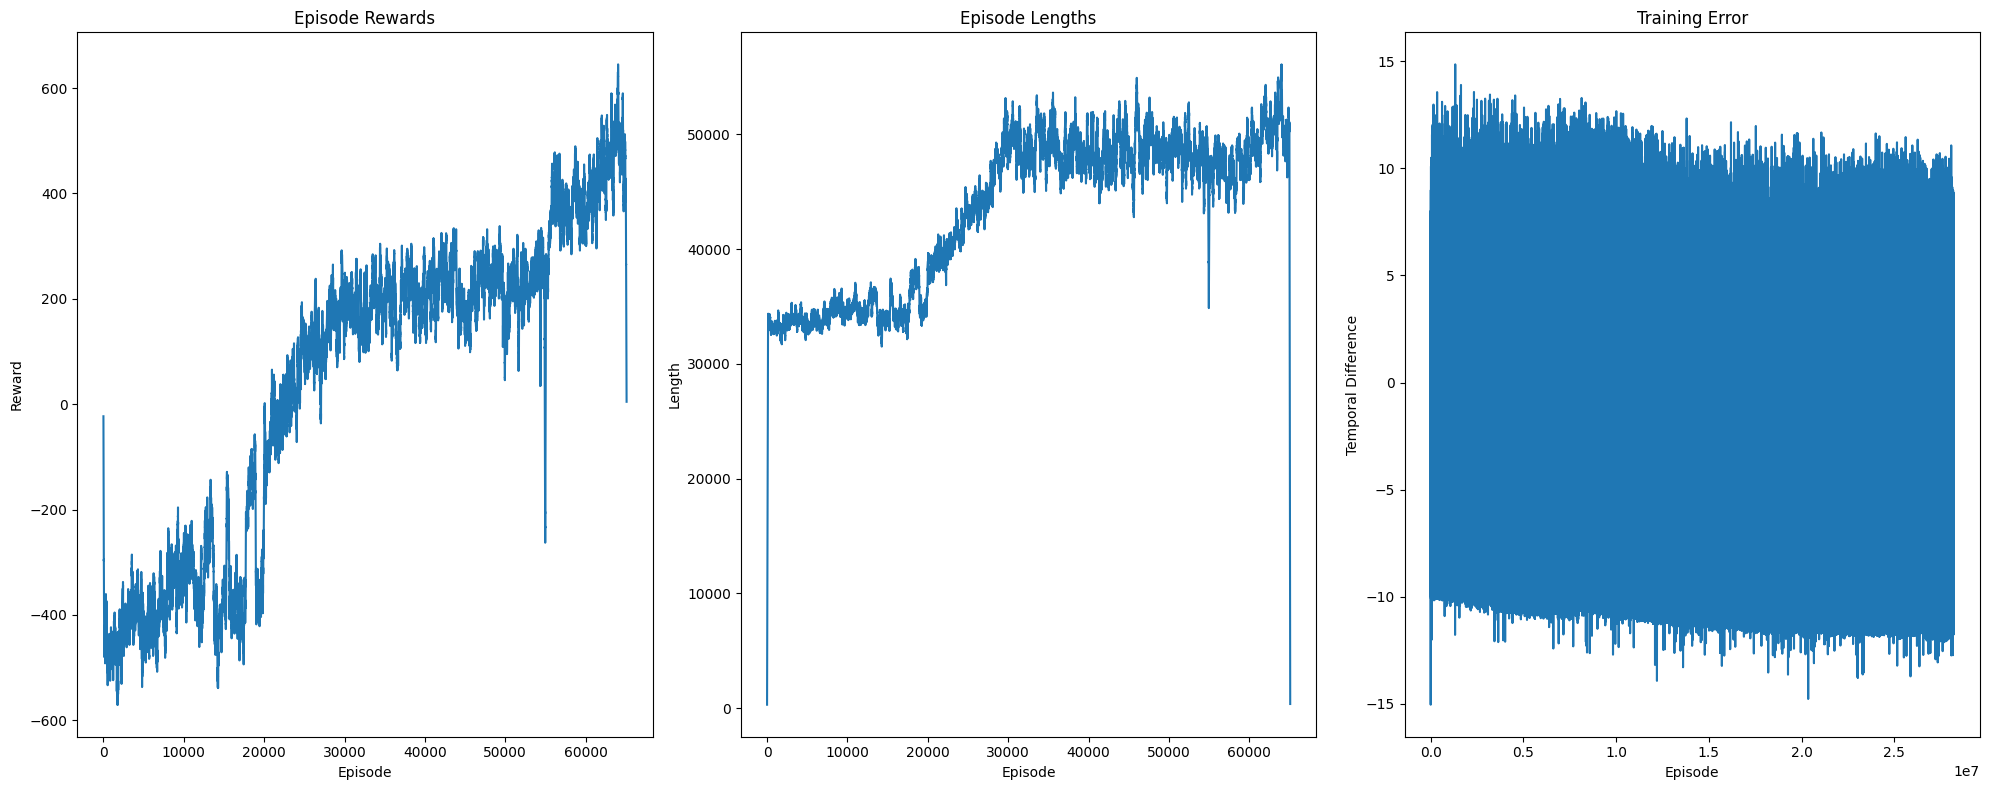

In [22]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

### Registrazione episodi

In [43]:
num_eval_episodes = 10

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env = ObsRewardWrapper(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval3",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)

In [44]:
for episode_num in range(num_eval_episodes):
    obs, info = env.reset()
    obs = tuple(obs)
    done = False
    while not done:
        action = agent.get_action(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        obs =  tuple(next_obs)

        done = terminated or truncated
env.close()

In [45]:
print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')
print("Training terminato")

Episode time taken: deque([0.685329, 0.62561, 0.641379, 0.643233, 0.675395, 0.708717, 0.727581, 0.752534, 0.596973, 0.760959], maxlen=10)
Episode total rewards: deque([-6.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, -3.0, 3.5], maxlen=10)
Episode lengths: deque([873, 873, 873, 873, 873, 873, 873, 873, 795, 1022], maxlen=10)
Training terminato


In [46]:
import shutil

dir_video =  dir + "/video_correct/"
if not os.path.exists(dir_video):
  os.makedirs(dir_video)

source_video = "/content/Q-Bert_RL/videos_first/"

for file_name in os.listdir(source_video):
   source_path = os.path.join(source_video, file_name)
   destination_path = os.path.join(dir_video, file_name)

   if os.path.isfile(source_path):
      shutil.copy2(source_path, destination_path)
      print(f"Copiato: {file_name}")

Copiato: eval3-episode-4.mp4
Copiato: eval3-episode-3.mp4
Copiato: eval3-episode-5.mp4
Copiato: eval3-episode-1.mp4
Copiato: eval3-episode-2.mp4
Copiato: eval3-episode-0.mp4
Copiato: eval3-episode-8.mp4
Copiato: eval3-episode-7.mp4
Copiato: eval3-episode-6.mp4
Copiato: eval3-episode-9.mp4
